# 연예인 눈썹 스타일 이식 파이프라인 (Diffusion + LoRA + ControlNet)
이 노트북은 고윤정, 홍수주, 신세경 등 연예인의 개성 있는 눈썹 스타일을 학습하고, 이를 사용자 이미지에 자연스럽게 이식하기 위한 모델링 및 학습 루프를 포함합니다.

**주요 구성:**
1. **Diffusion Model:** Stable Diffusion v1.5 (경량 및 범용성 최적화)
2. **LoRA (Low-Rank Adaptation):** 연예인별 특정 눈썹 스타일 학습을 위한 가중치 모듈
3. **ControlNet:** 마스킹 영역(눈썹)을 제한하여 정교한 생성을 제어하는 백본

In [1]:
# [Cell 1] 필수 라이브러리 설치 (torchao 버전 갈등 해결 버전)
# torchao를 0.16.0 이상으로 업데이트하여 peft의 내부 체크 기능을 만족시킵니다.
!pip install -q -U diffusers transformers accelerate peft opencv-python tqdm torchao>=0.16.0

In [ ]:
import os
import torch

drive.mount('/content/drive')

# 기본 경로 설정
BASE_PATH = '/content/drive/MyDrive/샘플/연예인얼굴'
MODEL_SAVE_PATH = '/content/drive/MyDrive/샘플/MODEL'
CELEBS = ['고윤정', '홍수주', '신세경']
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import torchao
print(torchao.__version__)

0.17.0


In [13]:
# [Cell 2] 데이터셋 및 로더 정의 (프롬프트 추가 버전)
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class EyebrowDataset(Dataset):
    def __init__(self, base_path, celebs, size=512):
        self.base_path = base_path
        self.celebs = celebs
        self.size = size
        self.image_paths = []

        for celeb in celebs:
            img_dir = os.path.join(base_path, celeb)
            mask_dir = os.path.join(base_path, f"{celeb}_mask", "extracted")

            if not os.path.exists(img_dir): continue

            for fname in os.listdir(img_dir):
                if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                    img_path = os.path.join(img_dir, fname)
                    base_name = os.path.splitext(fname)[0]
                    mask_name = f"{base_name}_tight_white_bg.png"
                    mask_path = os.path.join(mask_dir, mask_name)

                    if os.path.exists(mask_path):
                        # (이미지경로, 마스크경로, 연예인이름) 저장
                        self.image_paths.append((img_path, mask_path, celeb))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_p, mask_p, celeb_name = self.image_paths[idx]
        image = Image.open(img_p).convert("RGB").resize((self.size, self.size))
        mask = Image.open(mask_p).convert("L").resize((self.size, self.size))

        img_tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 127.5 - 1.0
        mask_tensor = torch.from_numpy(np.array(mask)).unsqueeze(0).float() / 255.0

        # [핵심] 트리거 워드 생성: "a photo of [연예인이름] style eyebrows"
        prompt = f"{celeb_name} style eyebrows"

        return {
            "pixel_values": img_tensor,
            "masks": mask_tensor,
            "prompt": prompt
        }

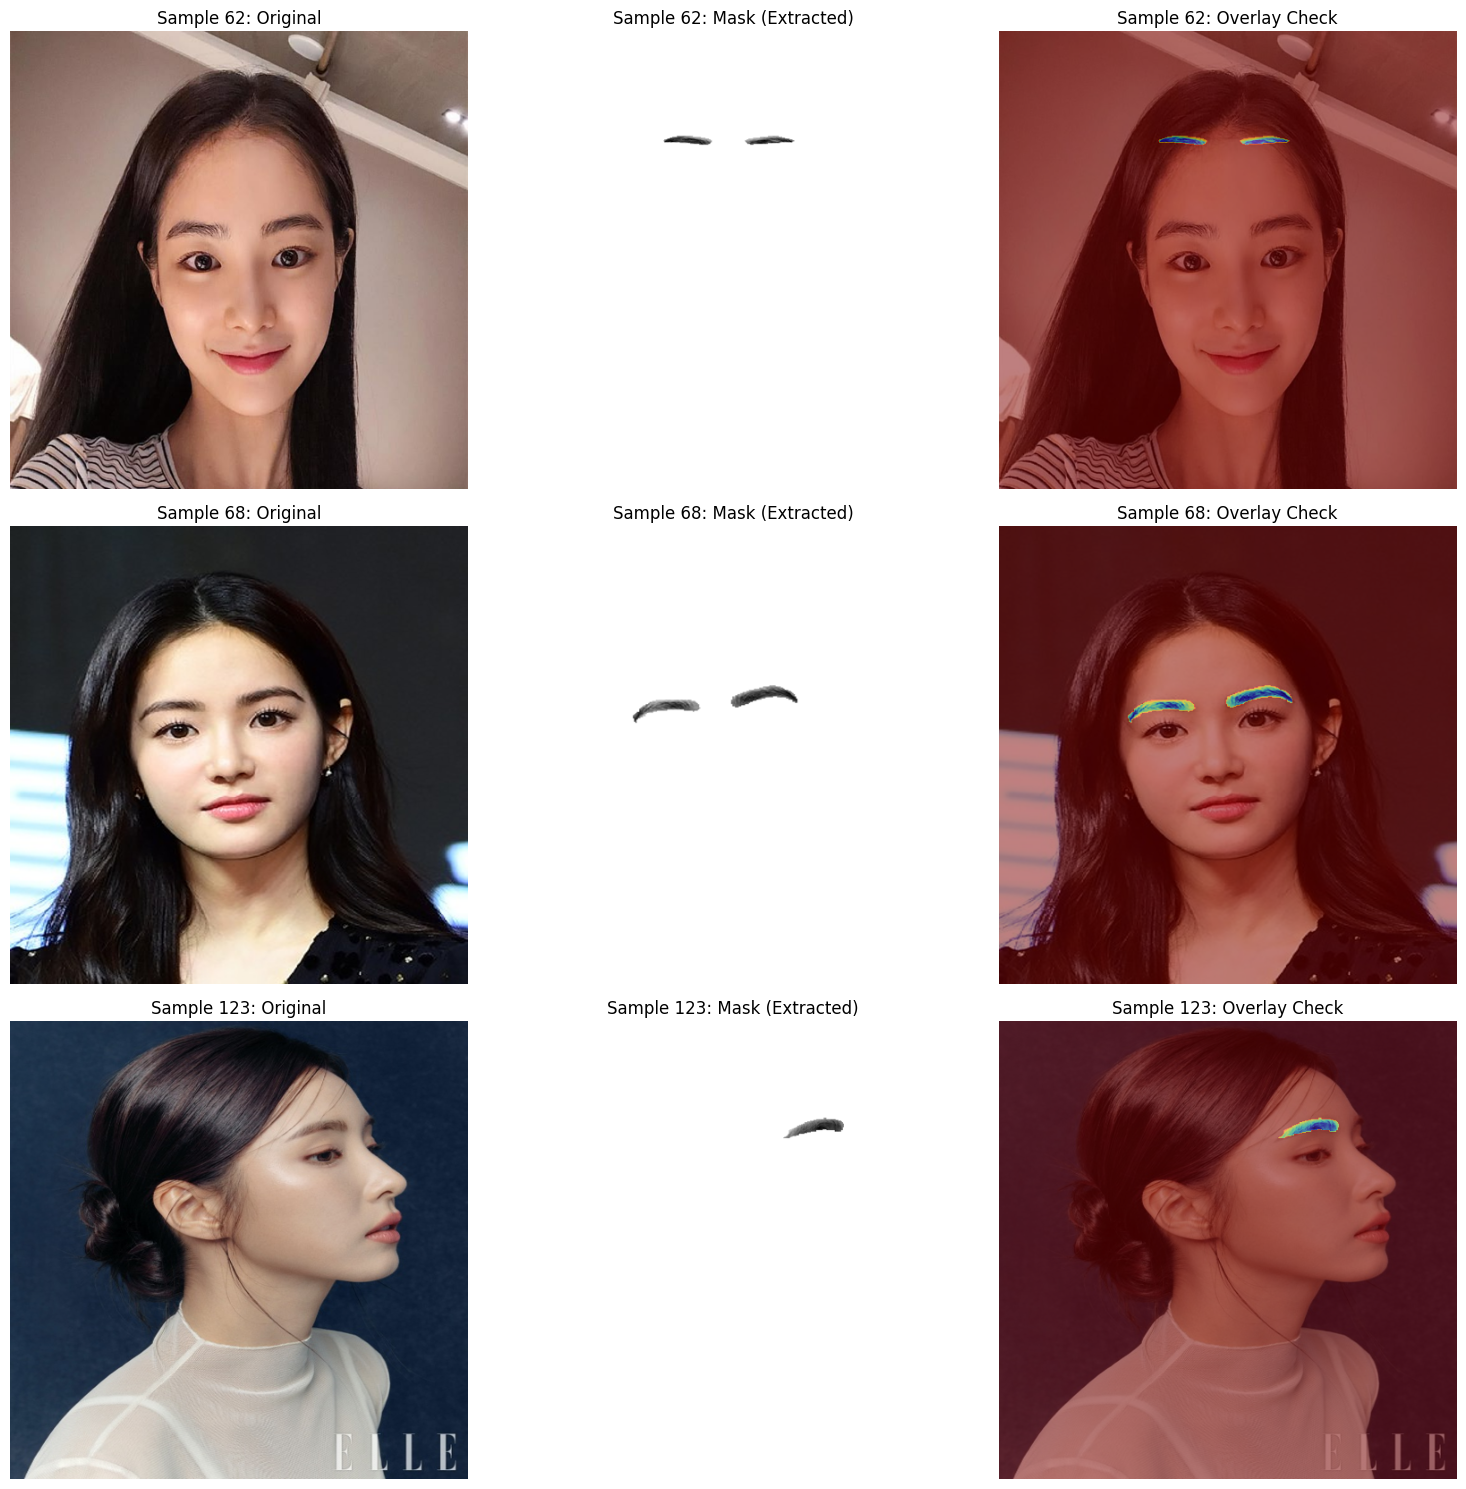

In [14]:
import matplotlib.pyplot as plt

def test_dataset_matching(dataset, num_samples=3):
    if len(dataset) == 0:
        print("❌ 테스트할 데이터가 없습니다. Cell 2의 경로 설정을 다시 확인하세요.")
        return

    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        # 무작위 샘플 인덱스
        idx = np.random.randint(0, len(dataset))
        sample = dataset[idx]

        # 텐서를 다시 이미지 형태로 변환
        # (C, H, W) -> (H, W, C), [-1, 1] -> [0, 1]
        img = (sample["pixel_values"].permute(1, 2, 0).numpy() + 1.0) / 2.0
        mask = sample["masks"].squeeze().numpy()

        # 원본 이미지
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f"Sample {idx}: Original")
        plt.axis('off')

        # 마스크 이미지 (Extracted)
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Sample {idx}: Mask (Extracted)")
        plt.axis('off')

        # 중첩 확인 (Overlaid)
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(img)
        plt.imshow(mask, alpha=0.5, cmap='jet') # 마스크를 반투명하게 겹침
        plt.title(f"Sample {idx}: Overlay Check")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 실행
dataset = EyebrowDataset(BASE_PATH, CELEBS)
test_dataset_matching(dataset)

### 모델 정의

## Diffusion

In [15]:
# [Cell 3] 모듈 1: Diffusion Backbone (Stable Diffusion v1.5)
# 이 모듈은 이미지를 생성하는 '기본 엔진'인 Stable Diffusion의 핵심 부품들을 로드합니다.

from diffusers import UNet2DConditionModel, AutoencoderKL
from transformers import CLIPTextModel

class DiffusionBackbone:
    """
    Stable Diffusion의 3대 핵심 요소(Text Encoder, VAE, UNet)를
    관리하고 불러오는 클래스입니다.
    """
    def __init__(self, model_id="runwayml/stable-diffusion-v1-5"):
        # 사용할 모델의 허브 ID를 저장합니다 (기본값: v1.5)
        self.model_id = model_id

    def load_modules(self):
        """
        각 기능을 담당하는 하위 모듈들을 사전 학습된 가중치로부터 로드합니다.
        """

        # 1. Text Encoder: 사용자가 입력한 텍스트 프롬프트를
        # 모델이 이해할 수 있는 '숫자 형태(임베딩)'로 번역하는 번역가 역할을 합니다.
        text_encoder = CLIPTextModel.from_pretrained(self.model_id, subfolder="text_encoder")

        # 2. VAE (Variational Autoencoder): 이미지를 작은 차원의 잠재 공간(Latent Space)으로
        # 압축하거나, 다시 고화질 이미지로 복원하는 '이미지 압축기/복원기'입니다.
        # 메모리 효율을 높이기 위해 실제 생성 작업은 압축된 공간에서 이루어집니다.
        vae = AutoencoderKL.from_pretrained(self.model_id, subfolder="vae")

        # 3. UNet: 실제 이미지 생성이 일어나는 '화가'의 심장부입니다.
        # 노이즈 상태에서 시작해 텍스트 정보를 참고하며 점점 구체적인 이미지를 그려나갑니다.
        # 눈썹 스타일 학습을 위한 LoRA와 구조 제어를 위한 ControlNet이 나중에 여기에 결합됩니다.
        unet = UNet2DConditionModel.from_pretrained(self.model_id, subfolder="unet")

        # 준비된 세 가지 핵심 모듈을 반환합니다.
        return text_encoder, vae, unet

## LoRA

In [7]:
# [Cell 4] 모듈 2: LoRA Adapter
# 이 모듈은 모델 전체를 재학습시키는 대신, 특정 부분에만 '어댑터'를 달아
# 연예인의 눈썹 스타일(결, 진하기 등)을 효율적으로 학습하게 합니다.

from peft import LoraConfig, get_peft_model

class LoRAAdapter:
    """
    고성능의 LoRA 설정을 정의하고, 이를 UNet 모델에 이식하는 클래스입니다.
    """
    def __init__(self, rank=8, alpha=32, target_modules=["to_k", "to_q", "to_v", "to_out.0"]):
        # 1. rank (r): 학습할 '정보의 양' 혹은 '두께'입니다.
        # 값이 작을수록 가볍고 빠르며, 값이 클수록(예: 16, 32) 더 복잡한 스타일을 배울 수 있습니다.

        # 2. lora_alpha: 학습된 스타일을 원본 모델에 얼마나 '강하게' 투영할지 결정하는 배율입니다.

        # 3. target_modules: UNet 내부의 'Attention' 레이어 중 학습 타겟이 될 행렬들입니다.
        # 이 부품들은 텍스트(프롬프트)와 이미지 사이의 관계를 계산하는 곳입니다.
        # - to_q (Query): "어디를 봐야 할까?" 이미지에서 특징을 찾는 질문기
        # - to_k (Key): "여기에 이런 특징이 있어" 이미지 정보를 분류하는 인덱스
        # - to_v (Value): "실제 스타일 정보는 이거야" 구체적인 색상/질감 데이터
        # - to_out.0: 위의 정보들을 종합하여 다음 단계로 전달하는 최종 통로

        self.config = LoraConfig(
            r=rank,                # 어댑터의 차원 (작을수록 효율적)
            lora_alpha=alpha,      # 스타일 반영 강도 스케일링
            target_modules=target_modules, # 스타일을 주입할 핵심 타겟 모듈들
            lora_dropout=0.05,     # 과적합(한 이미지에만 너무 똑같이 학습됨)을 방지하는 장치
            bias="none"            # 계산 단순화를 위해 편향값은 학습 제외
        )

    def apply_to_unet(self, unet):
        """
        정의된 LoRA 설정을 바탕으로 일반 UNet을 '학습 가능한 LoRA 모델'로 변환합니다.
        이제 모델 전체 파라미터 중 약 1% 미만의 데이터만 사용하여 눈썹 스타일을 배웁니다.
        """
        return get_peft_model(unet, self.config)

## ControlNet

In [8]:
# [Cell 5] 모듈 3: ControlNet
# 이 모듈은 생성될 이미지의 '구조'와 '형태'를 고정하는 역할을 합니다.
# 눈썹이 엉뚱한 곳에 그려지지 않도록 원본 얼굴의 위치 정보를 가이드로 제공합니다.

from diffusers import ControlNetModel
import torch

class ControlNetBackbone:
    """
    이미지의 외곽선이나 포즈 정보를 추출하여
    모델에게 '밑그림'을 강제로 지키게 만드는 ControlNet을 로드합니다.
    """
    def __init__(self, model_id="lllyasviel/sd-controlnet-canny"):
        # 1. model_id: 어떤 방식의 제어 도구를 사용할지 결정합니다.
        # - "sd-controlnet-canny": 이미지의 날카로운 외곽선(Edge)을 추출해 가이드로 사용합니다.
        # - "sd-controlnet-inpaint": 특정 영역(눈썹)을 비워두고 그 안만 채우도록 특화된 모델입니다.
        # 눈썹 스타일 이식에는 보통 원래 위치를 지키기 위해 Canny 방식이 효과적입니다.
        self.model_id = model_id

    def load(self):
        """
        사전 학습된 ControlNet 가중치를 로드합니다.
        """
        # torch_dtype=torch.float16:
        # 연산 정밀도를 절반으로 줄여 메모리 사용량을 획기적으로 낮추고 속도를 높입니다. (FP16 계산)
        return ControlNetModel.from_pretrained(
            self.model_id,
            torch_dtype=torch.float16
        )

## 모델 합치기

In [9]:
# [Cell 6] 통합 및 학습 준비 (Merge)
def initialize_pipeline(weight_dtype=torch.float16):
    # 1. 백본 로드
    db = DiffusionBackbone()
    text_encoder, vae, unet = db.load_modules()

    # 2. LoRA 적용
    la = LoRAAdapter()
    unet = la.apply_to_unet(unet)

    # 3. ControlNet 로드 (추후 구현 단계에서 활용)
    cn = ControlNetBackbone()
    controlnet = cn.load()

    return text_encoder, vae, unet, controlnet

text_encoder, vae, unet, controlnet = initialize_pipeline()
print("모듈 통합 완료: Diffusion + LoRA (Trainable) + ControlNet (Static)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

모듈 통합 완료: Diffusion + LoRA (Trainable) + ControlNet (Static)


In [16]:
# [Cell 7] 학습 루프 (연예인별 트리거 워드 + Masked Loss 적용)
from tqdm.auto import tqdm
import torch.nn.functional as F
from diffusers import DDPMScheduler
from transformers import CLIPTokenizer

def train_eyebrow_style(unet, vae, text_encoder, dataset, model_id="runwayml/stable-diffusion-v1-5", epochs=10, batch_size=1, lr=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1. 토크나이저 로드 (글자를 숫자로 바꾸는 도구)
    tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")

    unet.to(device)
    vae.to(device)
    text_encoder.to(device)

    optimizer = torch.optim.AdamW(unet.parameters(), lr=lr)
    noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")
    train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    unet.train()

    print(f"학습 시작: 장치={device}, 에폭={epochs}")

    for epoch in range(epochs):
        progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch}")
        for step, batch in enumerate(train_dataloader):
            pixel_values = batch["pixel_values"].to(device)
            masks = batch["masks"].to(device)
            prompts = batch["prompt"]

            # 2. VAE를 이용한 Latent 추출
            latents = vae.encode(pixel_values).latent_dist.sample().detach()
            latents = latents * 0.18215

            # 3. 마스크 크기를 Latent(64x64)에 맞게 조절
            mask_latent = F.interpolate(masks, size=(latents.shape[2], latents.shape[3]))

            # 4. 노이즈 추가 (Forward Diffusion)
            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # 5. [수정됨] 실제 프롬프트를 텍스트 인코더에 통과시켜 트리거 워드 활성화
            inputs = tokenizer(
                prompts,
                padding="max_length",
                max_length=tokenizer.model_max_length,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            # 텍스트의 '의미'를 담은 벡터 추출
            encoder_hidden_states = text_encoder(inputs.input_ids)[0]

            # 6. 예측 (UNet이 노이즈를 예측함)
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

            # 7. Masked MSE Loss 계산 (마스크 영역의 오차에만 집중)
            # 눈썹 영역만 오차를 계산하여 얼굴 다른 부분이 변하는 것을 방지합니다.
            loss = F.mse_loss(model_pred.float() * mask_latent, noise.float() * mask_latent, reduction="mean")

            # 8. 역전파 및 최적화
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            progress_bar.update(1)
            progress_bar.set_postfix({"loss": loss.item()})

    print("학습 완료! 연예인별 트리거 워드와 마스크 영역이 잘 결합되었습니다.")

    # 학습된 LoRA 가중치 저장 (경로는 본인의 구글 드라이브 환경에 맞게 수정)
    save_path = "/content/drive/MyDrive/샘플/MODEL/eyebrow_lora_final"
    unet.save_pretrained(save_path)
    print(f"모델이 다음 경로에 저장되었습니다: {save_path}")

In [17]:
# 실행
dataset = EyebrowDataset(BASE_PATH, ['신세경'])
train_eyebrow_style(unet, vae, text_encoder, dataset)

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

학습 시작: 장치=cuda, 에폭=10


...

Epoch 6:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 7:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/81 [00:00<?, ?it/s]

학습 완료! 연예인별 트리거 워드와 마스크 영역이 잘 결합되었습니다.
모델이 다음 경로에 저장되었습니다: /content/drive/MyDrive/샘플/MODEL/eyebrow_lora_final


## 잘 학습되었는가?

모델 로딩 중... (약 1분 소요)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


'신세경' 스타일로 변환을 시작합니다...


  0%|          | 0/18 [00:00<?, ?it/s]

변환 완료! 'transformed_eyebrow.png'로 저장되었습니다.


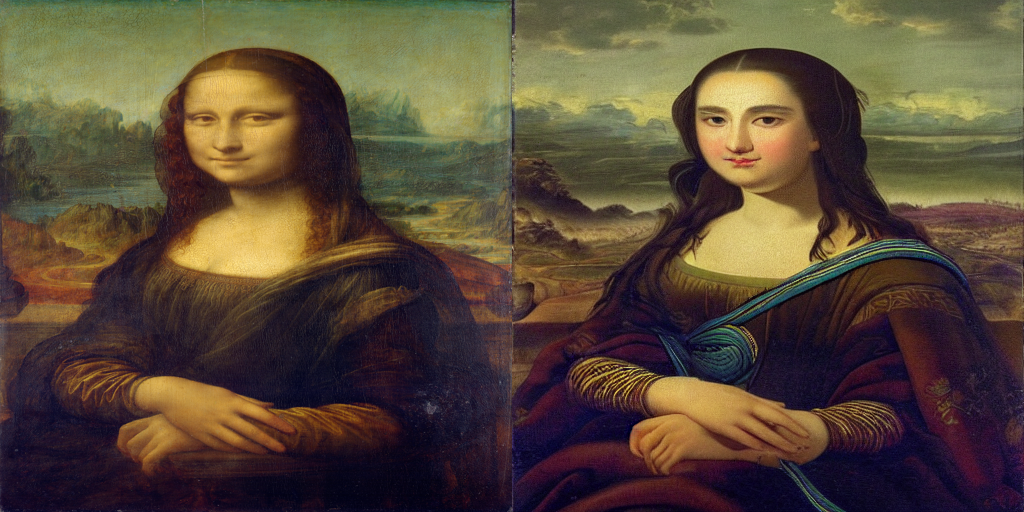

In [22]:
import torch
import cv2
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetImg2ImgPipeline, ControlNetModel
from diffusers.utils import load_image

# 1. 설정 및 경로
# ---------------------------------------------------------
base_model_id = "runwayml/stable-diffusion-v1-5"
controlnet_id = "lllyasviel/sd-controlnet-canny"
# 학습 시 저장했던 LoRA 폴더 경로
lora_model_path = "/content/drive/MyDrive/샘플/MODEL/eyebrow_lora_final"
# 변환할 일반인 사진 (사용자 이미지)
user_face_path = "test3.jpg"

# 2. 모델 및 파이프라인 로드
# ---------------------------------------------------------
print("모델 로딩 중... (약 1분 소요)")
controlnet = ControlNetModel.from_pretrained(controlnet_id, torch_dtype=torch.float16)
pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    base_model_id,
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# 학습된 LoRA 가중치를 파이프라인에 이식
pipe.load_lora_weights(lora_model_path)

# 3. 이미지 전처리 (Canny Edge 추출)
# ---------------------------------------------------------
# 원본 사진의 얼굴 윤곽과 눈썹 위치를 선으로 따서 가이드를 만듭니다.
def get_canny_guide(image):
    img = np.array(image)
    img = cv2.Canny(img, 100, 200) # 경계선 추출
    img = img[:, :, None]
    img = np.concatenate([img, img, img], axis=2)
    return Image.fromarray(img)

# 사용자 이미지 로드 및 리사이즈
init_image = load_image(user_face_path).resize((512, 512))
control_image = get_canny_guide(init_image)

# 4. 이미지 생성 (Inference)
# ---------------------------------------------------------
# celeb_style: 학습했던 연예인 폴더명 (GoYounJung, HongSuZu, ShinSaeKyeong 중 선택)
celeb_style = "신세경"
prompt = f"a photo of {celeb_style} style eyebrows, highly detailed, natural hair texture, masterpiece, 8k uhd"
negative_prompt = "blurry, messy, deformed, low quality, asymmetrical, cartoon, painting, mask, drawing"

print(f"'{celeb_style}' 스타일로 변환을 시작합니다...")

# 결과 생성
output_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,           # 베이스가 될 원본 사진
    control_image=control_image, # 위치를 고정할 밑그림
    strength=0.6,              # 변형 강도 (0.4~0.6 권장: 높을수록 눈썹이 더 많이 바뀜)
    controlnet_conditioning_scale=0.8, # ControlNet 영향력 (뼈대를 얼마나 지킬지)
    guidance_scale=7.5,         # 프롬프트 준수 강도
    num_inference_steps=30,     # 생성 단계
    cross_attention_kwargs={"scale": 0.8} # LoRA 스타일 반영 강도 (0.5~1.0)
).images[0]

# 5. 결과 확인 및 저장
# ---------------------------------------------------------
output_image.save("transformed_eyebrow.png")
print("변환 완료! 'transformed_eyebrow.png'로 저장되었습니다.")

# 원본과 결과 비교 출력
combined_result = Image.new('RGB', (1024, 512))
combined_result.paste(init_image, (0, 0))
combined_result.paste(output_image, (512, 0))
display(combined_result)